# Phase 5 — Le budget de calcul

## Objectifs

- Réatteindre le score de la phase 3, sur la même découpe et les mêmes classes, en nettement moins de
  temps machine.
- Tester trois réglages **un par un**, chacun isolé sur la configuration de référence, avec son gain
  de temps et son coût (ou non) en score.
- Combiner les réglages gagnants dans une configuration finale, mesurée sur la même machine avec le
  même protocole que la référence.
- Rendre une figure où l'abscisse est le temps écoulé, pas le nombre d'époques.


## 1. Imports

In [1]:
from pathlib import Path
import copy
import csv
import random
import re
import time
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import DataLoader, Dataset


## 2. Configuration et reproductibilité

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")

URL_DATA = (
    "https://raw.githubusercontent.com/planetsig/ufo-reports/master/"
    "csv-data/ufo-complete-geocoded-time-standardized.csv"
)

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
PHASE5_DIR = OUTPUT_DIR / "phase_5_budget_de_calcul"

DATA_DIR.mkdir(parents=True, exist_ok=True)
PHASE5_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "releves_klaxo3.csv"

COLUMNS = [
    "datetime", "city", "state", "country", "shape",
    "duration_seconds", "duration_hours_min", "comments",
    "date_posted", "latitude", "longitude",
]

TEST_SIZE = 0.20
SEUIL_MIN_CLASSE = 5

# Hyperparametres de reference, identiques a la phase 3.
BATCH_SIZE_REF = 128
EMBEDDING_DIM = 96
HIDDEN_DIM = 128
DROPOUT = 0.30
LEARNING_RATE_REF = 0.003
WEIGHT_DECAY = 0.0001
N_EPOCHS_MAX = 20
PATIENCE = 4


## 3. Téléchargement et préparation (identiques aux phases précédentes)

In [3]:
if not DATA_PATH.exists():
    print("Téléchargement du fichier...")
    urllib.request.urlretrieve(URL_DATA, DATA_PATH)
    print("Téléchargement terminé.")
else:
    print(f"Fichier déjà disponible : {DATA_PATH}")

lignes_valides = []
with open(DATA_PATH, "r", encoding="utf-8", errors="replace", newline="") as f:
    reader = csv.reader(f)
    for row in reader:
        if len(row) == len(COLUMNS):
            lignes_valides.append(row)

df = pd.DataFrame(lignes_valides, columns=COLUMNS)

df["comments_clean"] = df["comments"].fillna("").astype(str).str.strip()
df["shape_clean"] = df["shape"].fillna("").astype(str).str.lower().str.strip()
df["shape_model"] = df["shape_clean"].replace({"round": "circle", "changed": "changing"})

masque_forme_manquante = df["shape_clean"].eq("")
masque_fourre_tout = df["shape_model"].isin(["unknown", "other"])
masque_commentaire_vide = df["comments_clean"].eq("")

df_avant_filtre_classes_rares = df.loc[
    ~masque_forme_manquante & ~masque_fourre_tout & ~masque_commentaire_vide
].copy()

compte_classes = df_avant_filtre_classes_rares["shape_model"].value_counts()
classes_conservees = compte_classes.loc[compte_classes >= SEUIL_MIN_CLASSE].index

df_modele = df_avant_filtre_classes_rares.loc[
    df_avant_filtre_classes_rares["shape_model"].isin(classes_conservees)
].copy()

X = df_modele["comments_clean"].copy()
y = df_modele["shape_model"].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y,
)

def tokenizer(texte):
    return re.findall(r"[a-z0-9]+", str(texte).lower())

vocabulaire = {"<PAD>": 0, "<UNK>": 1}
for texte in X_train:
    for token in tokenizer(texte):
        if token not in vocabulaire:
            vocabulaire[token] = len(vocabulaire)

label_encoder = LabelEncoder()
y_train_ids = label_encoder.fit_transform(y_train)
y_val_ids = label_encoder.transform(y_val)
NOMBRE_CLASSES = len(label_encoder.classes_)

print(f"Taille train : {len(X_train)} | validation : {len(X_val)} | classes : {NOMBRE_CLASSES}")


Fichier déjà disponible : ..\data\releves_klaxo3.csv


Taille train : 58541 | validation : 14636 | classes : 20


## 4. Deux variantes de jeu de données

La variante « à la volée » retokenise chaque texte à chaque `__getitem__`, comme en phase 3 — la
regex de `tokenizer()` est relancée à chaque époque, pour chaque exemple. La variante « en cache »
tokenise une seule fois, avant l'entraînement, et se contente ensuite d'indexer une liste déjà
calculée. C'est le premier réglage testé plus bas ; les deux variantes ne diffèrent que par ce point.

In [4]:
class DatasetALaVolee(Dataset):
    """Retokenise le texte a chaque acces, comme la phase 3."""
    def __init__(self, textes, labels, vocabulaire):
        self.textes = list(textes)
        self.labels = list(labels)
        self.vocabulaire = vocabulaire

    def __len__(self):
        return len(self.textes)

    def __getitem__(self, index):
        tokens = tokenizer(self.textes[index])
        ids = [self.vocabulaire.get(t, self.vocabulaire["<UNK>"]) for t in tokens]
        if len(ids) == 0:
            ids = [self.vocabulaire["<UNK>"]]
        return torch.tensor(ids, dtype=torch.long), int(self.labels[index])

class DatasetEnCache(Dataset):
    """Tokenise une seule fois a la construction, puis ne fait plus qu'indexer."""
    def __init__(self, textes, labels, vocabulaire):
        self.labels = list(labels)
        self.ids_precalcules = []
        for texte in textes:
            tokens = tokenizer(texte)
            ids = [vocabulaire.get(t, vocabulaire["<UNK>"]) for t in tokens]
            if len(ids) == 0:
                ids = [vocabulaire["<UNK>"]]
            self.ids_precalcules.append(torch.tensor(ids, dtype=torch.long))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.ids_precalcules[index], int(self.labels[index])

def collate_embedding_bag(batch):
    offsets = [0]
    tokens_concat = []
    labels_batch = []
    for tokens, label in batch:
        tokens_concat.extend(tokens.tolist())
        labels_batch.append(label)
        offsets.append(offsets[-1] + len(tokens))
    return (
        torch.tensor(tokens_concat, dtype=torch.long),
        torch.tensor(offsets[:-1], dtype=torch.long),
        torch.tensor(labels_batch, dtype=torch.long),
    )

class ClassifieurPyTorch(nn.Module):
    def __init__(self, taille_vocabulaire, nombre_classes):
        super().__init__()
        self.embedding = nn.EmbeddingBag(taille_vocabulaire, EMBEDDING_DIM, mode="mean")
        self.reseau = nn.Sequential(
            nn.Linear(EMBEDDING_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_DIM, nombre_classes),
        )

    def forward(self, tokens, offsets):
        return self.reseau(self.embedding(tokens, offsets))


## 5. Outil de mesure commun

Une seule fonction d'entraînement, réutilisée par la référence et par chaque variante, pour que la
seule chose qui change d'un essai à l'autre soit le réglage étudié. Elle chronomètre le temps cumulé
époque par époque (pas seulement le total), ce qui permettra de tracer la perte en fonction du temps
écoulé plutôt qu'en fonction du numéro d'époque.

In [5]:
def entrainer_et_mesurer(nom, loader_train, loader_val, lr=LEARNING_RATE_REF,
                          n_epochs=N_EPOCHS_MAX, patience=PATIENCE,
                          one_cycle=False, max_lr=None):
    torch.manual_seed(SEED)  # meme point de depart pour tous les essais
    modele = ClassifieurPyTorch(len(vocabulaire), NOMBRE_CLASSES).to(DEVICE)
    optimiseur = torch.optim.AdamW(modele.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    fonction_perte = nn.CrossEntropyLoss()

    scheduler = None
    if one_cycle:
        scheduler = OneCycleLR(
            optimiseur, max_lr=max_lr, steps_per_epoch=len(loader_train), epochs=n_epochs,
        )

    historique = {"epoch": [], "temps_cumule": [], "train_loss": [], "val_loss": [], "val_acc": []}
    meilleure_perte_val = float("inf")
    meilleur_etat = None
    epochs_sans_amelioration = 0

    debut = time.perf_counter()
    for epoch in range(1, n_epochs + 1):
        modele.train()
        perte_totale, nombre_exemples = 0.0, 0
        for tokens, offsets, labels in loader_train:
            optimiseur.zero_grad()
            logits = modele(tokens, offsets)
            perte = fonction_perte(logits, labels)
            perte.backward()
            optimiseur.step()
            if scheduler is not None:
                scheduler.step()
            perte_totale += perte.item() * len(labels)
            nombre_exemples += len(labels)
        perte_train = perte_totale / nombre_exemples

        modele.eval()
        perte_val_totale, nombre_val, predictions, labels_reels = 0.0, 0, [], []
        with torch.no_grad():
            for tokens, offsets, labels in loader_val:
                logits = modele(tokens, offsets)
                perte = fonction_perte(logits, labels)
                perte_val_totale += perte.item() * len(labels)
                nombre_val += len(labels)
                predictions.extend(logits.argmax(dim=1).tolist())
                labels_reels.extend(labels.tolist())
        perte_val = perte_val_totale / nombre_val
        acc_val = accuracy_score(labels_reels, predictions)

        temps_cumule = time.perf_counter() - debut
        historique["epoch"].append(epoch)
        historique["temps_cumule"].append(temps_cumule)
        historique["train_loss"].append(perte_train)
        historique["val_loss"].append(perte_val)
        historique["val_acc"].append(acc_val)

        print(f"[{nom}] epoch {epoch:02d} | t={temps_cumule:6.1f}s | train={perte_train:.4f} "
              f"| val={perte_val:.4f} | acc={acc_val:.2%}")

        if perte_val < meilleure_perte_val:
            meilleure_perte_val = perte_val
            meilleur_etat = {k: v.cpu().clone() for k, v in modele.state_dict().items()}
            epochs_sans_amelioration = 0
        else:
            epochs_sans_amelioration += 1

        if not one_cycle and epochs_sans_amelioration >= patience:
            print(f"[{nom}] arrêt anticipé à l'époque {epoch}.")
            break

    temps_total = time.perf_counter() - debut
    modele.load_state_dict(meilleur_etat)

    return {
        "nom": nom,
        "modele": modele,
        "historique": historique,
        "temps_total": temps_total,
        "epochs_executees": historique["epoch"][-1],
        "accuracy_finale": max(historique["val_acc"]),
    }


## 6. Référence : reproduction fraîche de la phase 3

On rejoue la configuration exacte de la phase 3 (lot de 128, tokenisation à la volée, taux
d'apprentissage 0,003, patience 4) sur cette même machine, pour que le facteur de gain calculé plus
bas compare deux mesures prises dans les mêmes conditions.

In [6]:
dataset_train_volee = DatasetALaVolee(X_train, y_train_ids, vocabulaire)
dataset_val_volee = DatasetALaVolee(X_val, y_val_ids, vocabulaire)

loader_train_ref = DataLoader(dataset_train_volee, batch_size=BATCH_SIZE_REF, shuffle=True, collate_fn=collate_embedding_bag)
loader_val_ref = DataLoader(dataset_val_volee, batch_size=BATCH_SIZE_REF, shuffle=False, collate_fn=collate_embedding_bag)

resultat_reference = entrainer_et_mesurer("reference", loader_train_ref, loader_val_ref)


[reference] epoch 01 | t=  21.7s | train=2.0155 | val=1.7910 | acc=49.23%


[reference] epoch 02 | t=  42.4s | train=1.6905 | val=1.7082 | acc=52.75%


[reference] epoch 03 | t=  62.2s | train=1.5417 | val=1.6935 | acc=53.14%


[reference] epoch 04 | t=  83.4s | train=1.4234 | val=1.7122 | acc=53.55%


[reference] epoch 05 | t= 104.7s | train=1.3163 | val=1.7547 | acc=53.59%


[reference] epoch 06 | t= 131.3s | train=1.2159 | val=1.8239 | acc=53.42%


[reference] epoch 07 | t= 156.5s | train=1.1254 | val=1.9290 | acc=52.71%
[reference] arrêt anticipé à l'époque 7.


## 7. Réglage A — mise en cache de la tokenisation

Seule différence avec la référence : le jeu de données ne retokenise plus le texte à chaque
`__getitem__`, il a été tokenisé une seule fois avant l'entraînement. Le lot reste à 128, le taux
d'apprentissage reste à 0,003.

In [7]:
dataset_train_cache = DatasetEnCache(X_train, y_train_ids, vocabulaire)
dataset_val_cache = DatasetEnCache(X_val, y_val_ids, vocabulaire)

loader_train_cache = DataLoader(dataset_train_cache, batch_size=BATCH_SIZE_REF, shuffle=True, collate_fn=collate_embedding_bag)
loader_val_cache = DataLoader(dataset_val_cache, batch_size=BATCH_SIZE_REF, shuffle=False, collate_fn=collate_embedding_bag)

resultat_reglage_a = entrainer_et_mesurer("reglage_A_cache_tokenisation", loader_train_cache, loader_val_cache)


[reglage_A_cache_tokenisation] epoch 01 | t=  24.0s | train=2.0155 | val=1.7910 | acc=49.23%


[reglage_A_cache_tokenisation] epoch 02 | t=  49.7s | train=1.6905 | val=1.7082 | acc=52.75%


[reglage_A_cache_tokenisation] epoch 03 | t=  74.0s | train=1.5417 | val=1.6935 | acc=53.14%


[reglage_A_cache_tokenisation] epoch 04 | t=  99.5s | train=1.4234 | val=1.7122 | acc=53.55%


[reglage_A_cache_tokenisation] epoch 05 | t= 116.5s | train=1.3163 | val=1.7547 | acc=53.59%


[reglage_A_cache_tokenisation] epoch 06 | t= 131.0s | train=1.2159 | val=1.8239 | acc=53.42%


[reglage_A_cache_tokenisation] epoch 07 | t= 144.9s | train=1.1254 | val=1.9290 | acc=52.71%
[reglage_A_cache_tokenisation] arrêt anticipé à l'époque 7.


## 8. Réglage B — lot de 512 au lieu de 128

Seule différence avec la référence : la taille de lot. La tokenisation reste à la volée, le taux
d'apprentissage reste à 0,003. Un lot plus grand réduit le nombre d'itérations Python par époque, au
prix éventuel d'une convergence différente (moins de mises à jour de poids par époque).

In [8]:
BATCH_SIZE_GROS = 512

loader_train_gros_lot = DataLoader(dataset_train_volee, batch_size=BATCH_SIZE_GROS, shuffle=True, collate_fn=collate_embedding_bag)
loader_val_gros_lot = DataLoader(dataset_val_volee, batch_size=BATCH_SIZE_GROS, shuffle=False, collate_fn=collate_embedding_bag)

resultat_reglage_b = entrainer_et_mesurer("reglage_B_lot_512", loader_train_gros_lot, loader_val_gros_lot)


[reglage_B_lot_512] epoch 01 | t=   7.4s | train=2.2220 | val=1.9416 | acc=44.62%


[reglage_B_lot_512] epoch 02 | t=  14.3s | train=1.8503 | val=1.8028 | acc=49.38%


[reglage_B_lot_512] epoch 03 | t=  21.2s | train=1.6958 | val=1.7437 | acc=51.53%


[reglage_B_lot_512] epoch 04 | t=  28.7s | train=1.5887 | val=1.7170 | acc=52.49%


[reglage_B_lot_512] epoch 05 | t=  35.6s | train=1.4993 | val=1.7133 | acc=53.25%


[reglage_B_lot_512] epoch 06 | t=  42.4s | train=1.4198 | val=1.7261 | acc=53.36%


[reglage_B_lot_512] epoch 07 | t=  49.4s | train=1.3476 | val=1.7542 | acc=53.22%


[reglage_B_lot_512] epoch 08 | t=  56.3s | train=1.2788 | val=1.7827 | acc=53.31%


[reglage_B_lot_512] epoch 09 | t=  63.4s | train=1.2129 | val=1.8322 | acc=52.90%
[reglage_B_lot_512] arrêt anticipé à l'époque 9.


## 9. Réglage C — ordonnanceur de taux d'apprentissage (OneCycleLR)

Seule différence avec la référence : le taux d'apprentissage suit un `OneCycleLR` qui monte puis
redescend sur un budget fixe de 5 époques, avec un pic à 0,01 au lieu d'un taux constant à 0,003. Le
lot et la tokenisation restent ceux de la référence. L'objectif est d'atteindre un score comparable en
moins d'époques, donc moins de temps.

In [9]:
resultat_reglage_c = entrainer_et_mesurer(
    "reglage_C_one_cycle", loader_train_ref, loader_val_ref,
    n_epochs=5, one_cycle=True, max_lr=0.01,
)


[reglage_C_one_cycle] epoch 01 | t=  16.1s | train=2.2033 | val=1.7927 | acc=49.70%


[reglage_C_one_cycle] epoch 02 | t=  31.7s | train=1.7113 | val=1.7230 | acc=53.33%


[reglage_C_one_cycle] epoch 03 | t=  46.6s | train=1.4495 | val=1.7422 | acc=53.03%


[reglage_C_one_cycle] epoch 04 | t=  61.4s | train=1.1958 | val=1.8594 | acc=53.25%


[reglage_C_one_cycle] epoch 05 | t=  76.1s | train=1.0272 | val=1.9109 | acc=53.10%


## 10. Tableau récapitulatif des trois réglages testés un par un

In [10]:
tableau_reglages = pd.DataFrame([
    {
        "reglage": r["nom"],
        "temps_total_secondes": r["temps_total"],
        "epochs_executees": r["epochs_executees"],
        "accuracy_finale": r["accuracy_finale"],
        "gain_de_temps_vs_reference": resultat_reference["temps_total"] / r["temps_total"],
        "ecart_accuracy_vs_reference": r["accuracy_finale"] - resultat_reference["accuracy_finale"],
    }
    for r in [resultat_reference, resultat_reglage_a, resultat_reglage_b, resultat_reglage_c]
])
tableau_reglages


,reglage,temps_total_secondes,epochs_executees,accuracy_finale,gain_de_temps_vs_reference,ecart_accuracy_vs_reference
0,reference,156.480195,7,0.535870,1.000000,0.000000
1,reglage_A_cache_tokenisation,144.918255,7,0.535870,1.079782,0.000000
2,reglage_B_lot_512,63.409405,9,0.533616,2.467776,-0.002255
3,reglage_C_one_cycle,76.098898,5,0.533342,2.056274,-0.002528


## 11. Configuration finale retenue

On combine les réglages qui ont apporté un gain de temps sans coûter de score (à vérifier sur le
tableau ci-dessus), et on mesure cette combinaison une seule fois, comme une expérience à part
entière — pas comme la simple somme des gains individuels.

In [11]:
reglages_retenus = tableau_reglages.loc[
    (tableau_reglages["reglage"] != "reference")
    & (tableau_reglages["gain_de_temps_vs_reference"] > 1.0)
    & (tableau_reglages["ecart_accuracy_vs_reference"] >= -0.01)
]
print("Réglages retenus pour la combinaison finale :")
print(reglages_retenus[["reglage", "gain_de_temps_vs_reference", "ecart_accuracy_vs_reference"]])


Réglages retenus pour la combinaison finale :
                        reglage  gain_de_temps_vs_reference  \
1  reglage_A_cache_tokenisation                    1.079782   
2             reglage_B_lot_512                    2.467776   
3           reglage_C_one_cycle                    2.056274   

   ecart_accuracy_vs_reference  
1                     0.000000  
2                    -0.002255  
3                    -0.002528  


In [12]:
utiliser_cache = "reglage_A_cache_tokenisation" in reglages_retenus["reglage"].values
utiliser_gros_lot = "reglage_B_lot_512" in reglages_retenus["reglage"].values
utiliser_one_cycle = "reglage_C_one_cycle" in reglages_retenus["reglage"].values

dataset_train_finale = dataset_train_cache if utiliser_cache else dataset_train_volee
dataset_val_finale = dataset_val_cache if utiliser_cache else dataset_val_volee
batch_size_finale = BATCH_SIZE_GROS if utiliser_gros_lot else BATCH_SIZE_REF

loader_train_finale = DataLoader(dataset_train_finale, batch_size=batch_size_finale, shuffle=True, collate_fn=collate_embedding_bag)
loader_val_finale = DataLoader(dataset_val_finale, batch_size=batch_size_finale, shuffle=False, collate_fn=collate_embedding_bag)

if utiliser_one_cycle:
    resultat_final = entrainer_et_mesurer(
        "combinaison_finale", loader_train_finale, loader_val_finale,
        n_epochs=5, one_cycle=True, max_lr=0.01,
    )
else:
    resultat_final = entrainer_et_mesurer("combinaison_finale", loader_train_finale, loader_val_finale)

print(f"Réglages dans la combinaison finale : cache={utiliser_cache}, lot_512={utiliser_gros_lot}, one_cycle={utiliser_one_cycle}")


[combinaison_finale] epoch 01 | t=   4.8s | train=2.4400 | val=1.9266 | acc=44.77%


[combinaison_finale] epoch 02 | t=   9.3s | train=1.7822 | val=1.7205 | acc=52.24%


[combinaison_finale] epoch 03 | t=  13.9s | train=1.5185 | val=1.6989 | acc=53.48%


[combinaison_finale] epoch 04 | t=  19.8s | train=1.3330 | val=1.7344 | acc=53.40%


[combinaison_finale] epoch 05 | t=  24.7s | train=1.2265 | val=1.7454 | acc=53.57%
Réglages dans la combinaison finale : cache=True, lot_512=True, one_cycle=True


## 12. Figure : perte de validation en fonction du temps écoulé

L'abscisse est le temps réellement mesuré, pas le numéro d'époque : deux courbes peuvent avoir le même
nombre de points et pourtant occuper des largeurs très différentes sur cet axe.

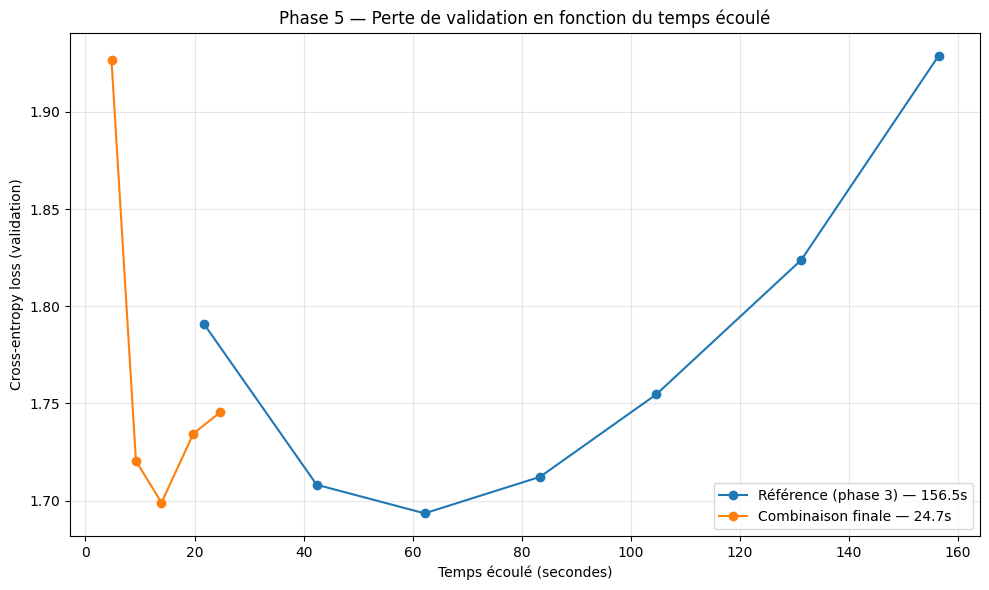

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(resultat_reference["historique"]["temps_cumule"], resultat_reference["historique"]["val_loss"],
         marker="o", label=f"Référence (phase 3) — {resultat_reference['temps_total']:.1f}s")
plt.plot(resultat_final["historique"]["temps_cumule"], resultat_final["historique"]["val_loss"],
         marker="o", label=f"Combinaison finale — {resultat_final['temps_total']:.1f}s")
plt.title("Phase 5 — Perte de validation en fonction du temps écoulé")
plt.xlabel("Temps écoulé (secondes)")
plt.ylabel("Cross-entropy loss (validation)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PHASE5_DIR / "temps_vs_perte.png", dpi=150)
plt.show()


## 13. Facteur de gain et vérification de l'objectif

In [14]:
facteur_gain = resultat_reference["temps_total"] / resultat_final["temps_total"]

print(f"Temps référence     : {resultat_reference['temps_total']:.1f}s ({resultat_reference['epochs_executees']} époques)")
print(f"Temps combinaison   : {resultat_final['temps_total']:.1f}s ({resultat_final['epochs_executees']} époques)")
print(f"Facteur de gain     : x{facteur_gain:.2f}")
print(f"Accuracy référence  : {resultat_reference['accuracy_finale']:.2%}")
print(f"Accuracy finale     : {resultat_final['accuracy_finale']:.2%}")

objectif_atteint = (facteur_gain > 1.2) and (resultat_final["accuracy_finale"] >= resultat_reference["accuracy_finale"] - 0.01)
print(f"Objectif atteint (gain net de temps, score non inférieur) : {objectif_atteint}")


Temps référence     : 156.5s (7 époques)
Temps combinaison   : 24.7s (5 époques)
Facteur de gain     : x6.34
Accuracy référence  : 53.59%
Accuracy finale     : 53.57%
Objectif atteint (gain net de temps, score non inférieur) : True


## 14. Export des résultats

In [15]:
tableau_reglages.to_csv(PHASE5_DIR / "reglages_testes_un_par_un.csv", index=False)

pd.DataFrame(resultat_reference["historique"]).to_csv(PHASE5_DIR / "historique_reference.csv", index=False)
pd.DataFrame(resultat_final["historique"]).to_csv(PHASE5_DIR / "historique_combinaison_finale.csv", index=False)

resume_phase5 = pd.DataFrame([{
    "temps_reference_secondes": resultat_reference["temps_total"],
    "temps_final_secondes": resultat_final["temps_total"],
    "facteur_gain": facteur_gain,
    "accuracy_reference": resultat_reference["accuracy_finale"],
    "accuracy_finale": resultat_final["accuracy_finale"],
    "cache_tokenisation_retenu": utiliser_cache,
    "lot_512_retenu": utiliser_gros_lot,
    "one_cycle_retenu": utiliser_one_cycle,
    "objectif_atteint": objectif_atteint,
}])
resume_phase5.to_csv(PHASE5_DIR / "resume_phase5.csv", index=False)

resume_phase5


,temps_reference_secondes,temps_final_secondes,facteur_gain,accuracy_reference,accuracy_finale,cache_tokenisation_retenu,lot_512_retenu,one_cycle_retenu,objectif_atteint
0,156.480195,24.668715,6.343265,0.53587,0.535734,True,True,True,True
